# Model Trianing 
- Trained Linear Regression model
- Evaluated the model with MAE,RMSE and R2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("..\data\processed\cleaned_dataset.csv")

In [3]:
df.shape

(1456, 205)

In [4]:
# separation of input and output features

#target variable
y= df["SalePrice"]

# Input features
X = df.drop("SalePrice", axis=1)

print("X Shape:", X.shape)
print("y shape:" ,y.shape)

X Shape: (1456, 204)
y shape: (1456,)


In [5]:
# train-test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1164, 204)
X_test shape: (292, 204)
y_train shape: (1164,)
y_test shape: (292,)


In [6]:
# creating model and training

from sklearn.linear_model import LinearRegression

# creating model object
linear_model = LinearRegression()

#train the model
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# predictions
y_pred = linear_model.predict(X_test)

In [8]:
# predictions
y_pred = linear_model.predict(X_test)

In [9]:
# model evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 =r2_score(y_test, y_pred)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2 score:", r2)

MAE: 17667.97008131381
RMSE: 23700.65417820604
R2 score: 0.8929732782285021


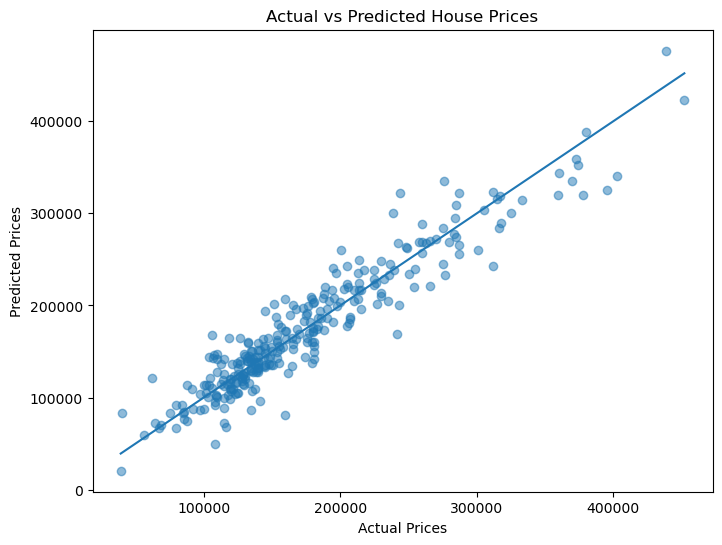

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()])
plt.show()

In [12]:
# Cross validation
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1,10,50,100]

ridge_cv= RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train,y_train)

print("Best alpha:",ridge_cv.alpha_)


Best alpha: 10.0


In [14]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([("scaler", StandardScaler()),("ridge", Ridge(alpha=ridge_cv.alpha_))])
pipeline.fit(X_train, y_train)
y_pred_ridge = pipeline.predict(X_test)

mae_ridge = mean_absolute_error(y_pred_ridge,y_test)
rmse_ridge = np.sqrt(mean_squared_error(y_pred_ridge,y_test))
r2_ridge = r2_score(y_pred_ridge,y_test)

print("Ridge Results:")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Ridge Results:
MAE: 17468.488300261255
RMSE: 23591.7725205966
R2: 0.889419194497635


In [15]:
# Model Comparisons

results = pd.DataFrame({
    "Model" : ["Linear", "Ridge"],
    "MAE" : [mae , mae_ridge],
    "RMSE" : [rmse,rmse_ridge],
    "R2" : [r2, r2_ridge]
 })
results

,Model,MAE,RMSE,R2
0,Linear,17667.970081,23700.654178,0.892973
1,Ridge,17468.488300,23591.772521,0.889419


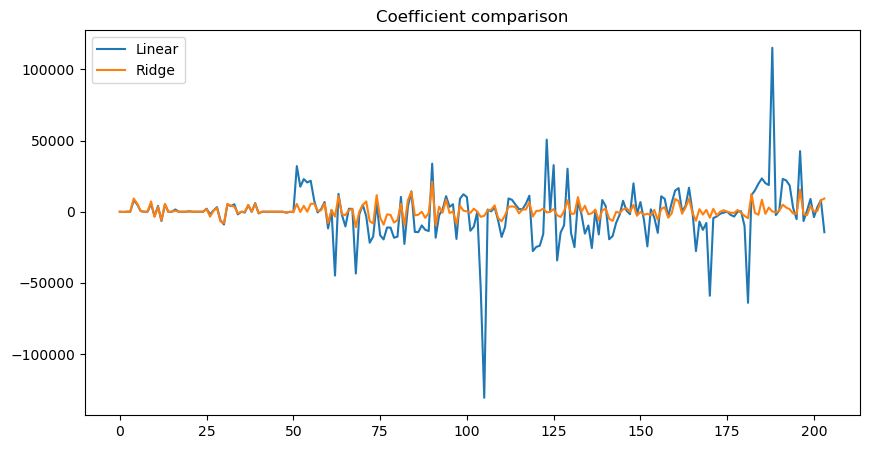

In [16]:
plt.figure(figsize=(10,5))
plt.plot(linear_model.coef_, label="Linear")
plt.plot(ridge_cv.coef_, label="Ridge")
plt.legend()
plt.title("Coefficient comparison")
plt.show()